# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from cross_sections_stats import *
%matplotlib inline
pd.set_option('display.max_rows', None)

### Provide Directories

#### Provide the directory for transmission images

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\02_Transmission_results\exp102_stats"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [3]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\00_Raw_sorted\exp102\005_temp_01_p10_batch01\exp102_031_Spectra.txt"

#### Provide the directory for saving results

In [4]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\testing_CS_stats"

In [5]:
flight_path = 5.45

## Remove Casing 
read the directory and extract values from images

In [6]:
stack_dict = read_saved_dict (src_dir, proc_folder = ['003_temp_00_p20_batch03'])

Reading Images: 100%|████████████████████████████| 1/1 [00:07<00:00,  7.62s/it]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [7]:
avg_imgs = []
for key, value in stack_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_slice = 40, end_slice = 50)
    avg_imgs.append(img[0])

#### Select the Casing ROI
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [8]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
#ROIs_003_temp_00_p20_batch03  = [[58, 296, 234, 54]]
ROIs_003_temp_00_p20_batch03  = [[112, 288, 188, 70]]

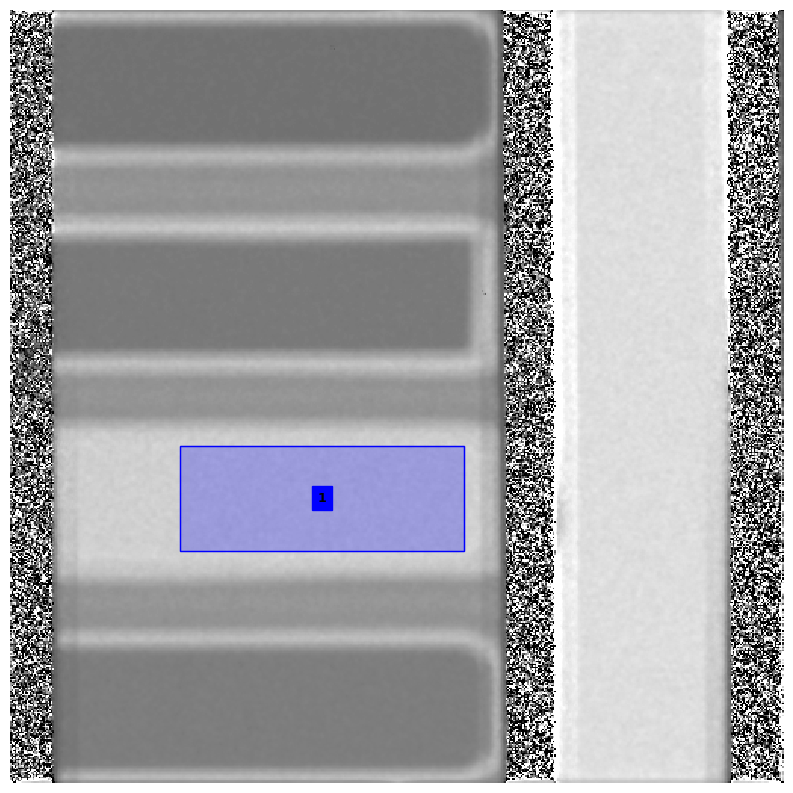

In [9]:
show_img(avg_imgs[0], dr = [(ROIs_003_temp_00_p20_batch03, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [10]:
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

In [15]:
cas_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\02_Transmission_results\exp102"

In [16]:
cas_dict = read_saved_dict (cas_dir, proc_folder = ['003_temp_00_p20_batch03'])

Reading Images: 100%|████████████████████████████| 1/1 [00:00<00:00,  2.00it/s]


In [17]:
val_casing = get_roi_values (cas_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [18]:
val_casing

,Wavelength [Å],Values_acq_0
0,0.072588,0.918308
1,0.130658,0.917819
2,0.188728,0.909702
3,0.246798,0.908697
4,0.304869,0.910439
5,0.362939,0.915105
6,0.421009,0.914689
7,0.479079,0.907869
8,0.537150,0.912745
9,0.595220,0.906290


## Process a single  experiment

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [19]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
ROIs_003_temp_00_p20_batch03  = [[52, 166, 231, 43]]
#ROIs_003_temp_00_p20_batch03  = [[58, 441, 234, 43], [52, 166, 231, 43], [58, 296, 234, 54], [58, 27, 231, 43]]

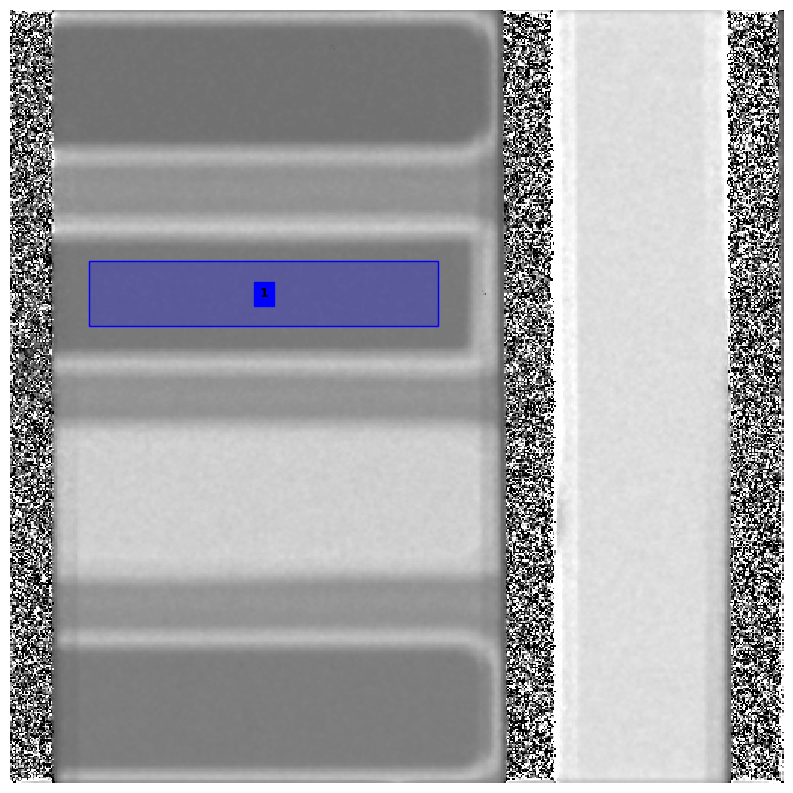

In [20]:
show_img(avg_imgs[0], dr = [(ROIs_003_temp_00_p20_batch03, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [21]:
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [22]:
val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 1, 
                                 flight_path = flight_path, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [23]:
#val_rois = table_val_rois.loc[3:76, :]
#val_rois = table_val_rois.reset_index(drop=True)

val_rois

,Wavelength [Å],Values_acq_0,Values_acq_1,Values_acq_2,Values_acq_3,Values_acq_4,Values_acq_5
0,0.072588,0.205575,0.198624,0.200409,0.200615,0.200951,0.202996
1,0.130658,0.212865,0.208886,0.215240,0.204426,0.220009,0.211830
2,0.188728,0.212950,0.217152,0.225135,0.224998,0.220504,0.219339
3,0.246798,0.218779,0.234796,0.227412,0.229641,0.231672,0.235168
4,0.304869,0.232583,0.234271,0.243775,0.232111,0.235634,0.242536
5,0.362939,0.248902,0.245600,0.243651,0.246959,0.247774,0.249138
6,0.421009,0.249588,0.251186,0.254126,0.254654,0.247610,0.249061
7,0.479079,0.251697,0.252406,0.255685,0.262433,0.258824,0.259990
8,0.537150,0.257576,0.261401,0.262391,0.264086,0.256194,0.257732
9,0.595220,0.271045,0.266027,0.264251,0.261861,0.261017,0.258754


### Remove the casing


In [24]:
trans_rois = divide_DF (val_rois, val_casing)

In [25]:
trans_rois

,Wavelength [Å],Values_acq_0,Values_acq_1,Values_acq_2,Values_acq_3,Values_acq_4,Values_acq_5
0,0.072588,0.223863,0.216294,0.218237,0.218462,0.218827,0.221054
1,0.130658,0.231925,0.227590,0.234512,0.222730,0.239709,0.230798
2,0.188728,0.234088,0.238707,0.247482,0.247331,0.242391,0.241110
3,0.246798,0.240761,0.258388,0.250261,0.252715,0.254950,0.258797
4,0.304869,0.255462,0.257317,0.267756,0.254944,0.258813,0.266394
5,0.362939,0.271993,0.268385,0.266254,0.269869,0.270761,0.272251
6,0.421009,0.272867,0.274613,0.277828,0.278405,0.270704,0.272291
7,0.479079,0.277240,0.278021,0.281632,0.289065,0.285090,0.286374
8,0.537150,0.282200,0.286390,0.287474,0.289332,0.280685,0.282371
9,0.595220,0.299071,0.293534,0.291575,0.288938,0.288006,0.285509


### H cross section parameters

In [26]:
thickness = 0.3
h2o = {'abbv': 'H2O','composition' : {'H':2.0, 'O':1.0},'density':0.997, 'thickness': thickness}
ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.28, 'thickness': thickness}
ec_dmc_11w = {'abbv': 'EC_DMC (1:1w)','molecules' : [ec,0.447511501,dmc,0.552488499], 'density':1.2335, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#ec_dec_37w = {'abbv': 'EC_DEC (3:7w)','molecules' : [ec,0.240305619,dec,0.759694381], 'density':1.0705, 'thickness': thickness}
lp30 = {'abbv': 'LP30','molecules' : [ec, 0.406359477,dmc, 0.501683056, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}
lp47 = {'abbv': 'LP47','molecules' : [ec, 0.218207723,dec, 0.689834809, lipf6 ,0.091957467], 'density':1.1685, 'thickness': thickness}
#ec_dec_sol = {'abbv': 'EC_DEC (sol)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
pe = {'abbv': 'PE', 'composition' : {'C':1.0, 'H':2.0},'density':0.92, 'thickness': 0.22}

## exp1000 -> LP30


In [27]:
compounds_dict = [pe, pe, pe, pe, pe, pe]

### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

In [28]:
requested_cs = ['h_cs']
cs_table = get_cross_sections (trans_rois, compounds_dict, requested_cs, dst_dir = dst_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')

In [29]:
cs_table

,Wavelength [Å],CS_H_in_PE_Values_acq_0,CS_H_in_PE_Values_acq_1,CS_H_in_PE_Values_acq_2,CS_H_in_PE_Values_acq_3,CS_H_in_PE_Values_acq_4,CS_H_in_PE_Values_acq_5
0,0.072588,83.747728,85.726849,85.212278,85.152989,85.056757,84.474140
1,0.130658,81.712049,82.797627,81.073567,84.039480,79.812548,81.992296
2,0.188728,81.177874,80.053560,77.976289,78.011340,79.172169,79.477031
3,0.246798,79.560501,75.494931,77.333699,76.772245,76.265707,75.403844
4,0.304869,76.149881,75.733556,73.445426,76.266640,75.399942,73.738791
5,0.362939,72.540701,73.309139,73.767687,72.991724,72.801979,72.486139
6,0.421009,72.354690,71.987599,71.317870,71.198580,72.812621,72.476345
7,0.479079,71.438228,71.276364,70.533767,69.034904,69.831663,69.572962
8,0.537150,70.416032,69.567850,69.350495,68.979968,70.725621,70.381187
9,0.595220,67.072808,68.148120,68.533491,69.056261,69.242083,69.743190


In [30]:
cs_ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI"
cs_ref_data = pd.read_csv (cs_ref_dir + '\cs_ref_IMAT20.txt',sep='\t')
cs_ref_data = cs_ref_data.loc[0:93, ['orig wvl','orig cs LP30', 'orig cs PE']]
cs_ref_data = cs_ref_data.reset_index(drop=True)
cs_ref_data

,orig wvl,orig cs LP30,orig cs PE
0,0.764306,33.804776,31.284488
1,0.822177,35.737919,33.045642
2,0.880048,37.725214,35.043827
3,0.937919,39.953408,36.966376
4,0.995790,42.166055,39.037189
5,1.053661,44.077816,41.065673
6,1.111533,45.960390,43.014795
7,1.169404,47.779011,44.856225
8,1.227275,49.188956,46.486678
9,1.285146,50.801343,48.109889


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


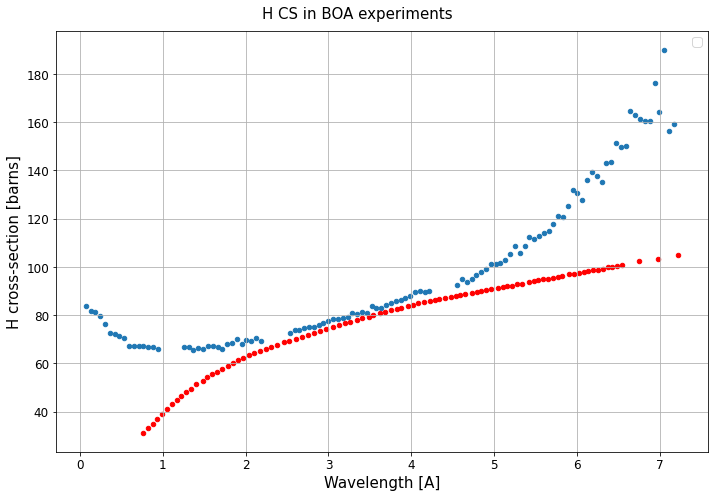

In [31]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table.plot.scatter(x='Wavelength [Å]', y=['CS_H_in_PE_Values_acq_0'])
cs_ref_data.plot(ax = ax, x='orig wvl', y=['orig cs PE'], 
                 grid = True, fontsize = 12, kind = 'scatter', color = 'r')

plt.suptitle('H CS in BOA experiments', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("H cross-section [barns]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()

## Option to make the relative attenuation images 


In [ ]:
HE_n_LE = ([15,30],[70,85])

trans_imgs_dict = read_saved_dict (src_dir, proc_folder = [])

In [ ]:
proc_folder1 = [key for key in trans_imgs_dict.keys() if 'batch01' in key]
proc_folder2 = [key for key in trans_imgs_dict.keys() if 'batch02' in key]
proc_folder3 = [key for key in trans_imgs_dict.keys() if 'batch03' in key]

In [ ]:
res_stack = get_relative_att_stack (trans_imgs_dict, dst_dir, HE_n_LE, proc_folder = proc_folder1, save=False)